# Deterministic Scenario Analysis

Recreate the base, optimistic and pessimistic cashflow comparisons from Chapter 4 of {cite}`farevuu2018`. The governing equations are stored in Models. A Specification supplies solve roles; accepted results are new immutable revisions.

## Goal
Compare operating cashflows, values and dated IRRs across holding periods. Each potential sale includes that period's operating cashflow and next-period income capitalized at the declared rate. Alternative holding periods are hindsight comparisons.

## Setup

In [1]:
%matplotlib inline
from datetime import date
from uuid import uuid4
import os, sys
import pandas as pd  # Detached tables for presentation only.
import matplotlib.pyplot as plt
import rangekeeper as rk
from rangekeeper.examples import investment
from rangekeeper.io import MemoryStore
from rangekeeper.execution import Executor
from rangekeeper.run import validate
from rangekeeper.adapters.plotting import plot_flows, plot_distribution, plot_pairs
from rangekeeper.calculations import series
from rangekeeper.model import Model, Metadata
from rangekeeper.model.flow import Flow, Movement
from rangekeeper.duration import make_periods
from rangekeeper.model.distribution import Distribution
from rangekeeper.scenarios import market, replay
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.prop_cycle': plt.cycler(color=['#285f8f','#cf8b2e','#9c557a','#627c49','#737373'])})
print('Installed package:', rk.__file__)
assert not {'rangekeeper.flux','rangekeeper.dynamics','rangekeeper.policy','rangekeeper._legacy_duration'} & set(sys.modules)

Installed package: /private/tmp/rk-turn4-wheel/site/rangekeeper/__init__.py


In [2]:
def execute(model, specification):
    store = MemoryStore()
    store.put(model)
    run = Executor(store).execute(specification)
    validate(run, resolver=store).raise_if_invalid()
    assert run.report.status.solution == 'feasible', [(d.code, d.message) for d in run.report.diagnostics]
    output = store.load_model(run.record.outputs[0])
    return investment.report(output), run

def metrics(result):
    return {'PV (AUD)': result.pv.magnitude, 'NPV (AUD)': result.npv.magnitude,
            'Dated IRR (%)': 100 * result.irr.rate, 'Sale date': result.sale_date}

## Steps
### 1. Declare inputs
The base has 2% annual growth, 5% vacancy, 35% operating expenses, 10% capital expenses, a 5% capitalization rate and a 7% discount rate. Acquisition costs AUD 1,000 at the end of 2020. Operating amounts have AUD units; the annual cadence is declared by their periods.

In [3]:
parameters = {'base': {}, 'optimistic': {'initial_pgi': 110., 'addl_pgi_per_period': 3.}, 'pessimistic': {'initial_pgi': 90., 'addl_pgi_per_period': -3.}}
authored = {name: investment.author(changes) for name, changes in parameters.items()}

### 2. Declare equations

In [4]:
models = {name: investment.formulate(model) for name, model in authored.items()}
print('Equations declared; result magnitudes are still unresolved.')

Equations declared; result magnitudes are still unresolved.


### 3. Assign inputs and solve

In [5]:
specifications = {name: investment.specify(model) for name, model in models.items()}
results = {name: execute(models[name], specifications[name])[0] for name in models}
pd.DataFrame({name: metrics(result) for name, result in results.items()}).T

,PV (AUD),NPV (AUD),Dated IRR (%),Sale date
base,1000.0,-0.0,6.996148,2030-12-31
optimistic,1294.078115,294.078115,10.415964,2030-12-31
pessimistic,705.921885,-294.078115,2.446045,2030-12-31


### 4. Inspect component cashflows

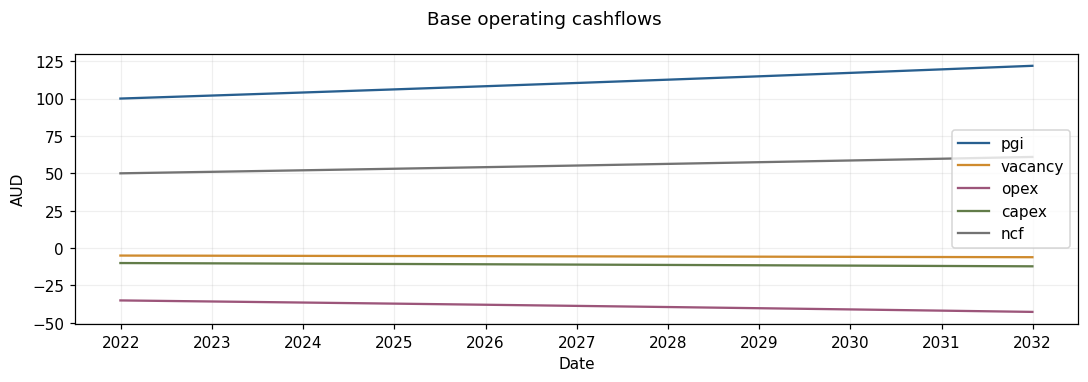

In [6]:
base = investment.values(results['base'].model)
plot_flows({name: base[name].flow for name in ('pgi','vacancy','opex','capex','ncf')}, title='Base operating cashflows');

### 5. Compare sale horizons

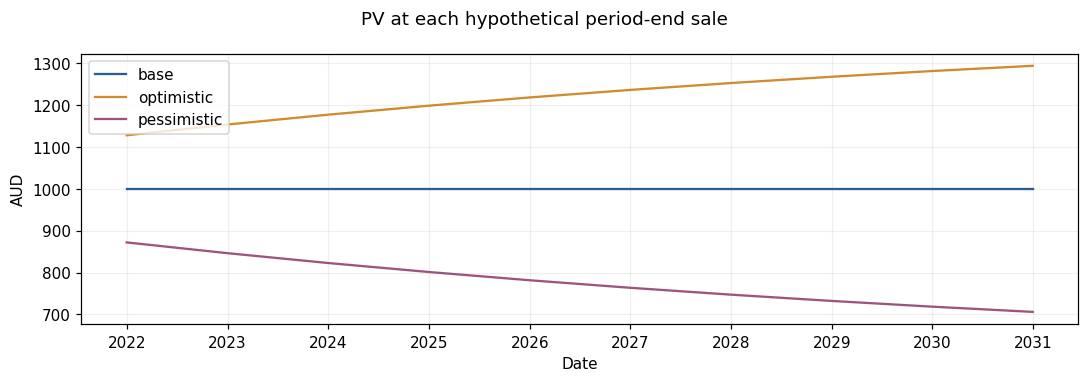

In [7]:
curves = {name: investment.values(result.model)['horizon_pv'].flow for name, result in results.items()}
plot_flows(curves, title='PV at each hypothetical period-end sale');

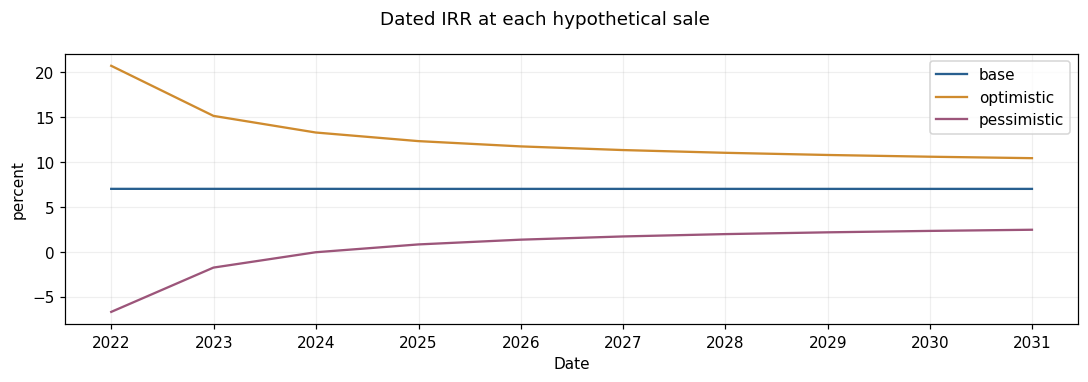

In [8]:
plot_flows({name: investment.horizon_returns(result.model) for name, result in results.items()}, title='Dated IRR at each hypothetical sale');

### 6. Compare expected value and hindsight selection
Use equal scenario probabilities for this teaching example. The maximum after seeing a complete path is a hindsight bound. It is not an implementable policy or a promise of peak sale timing.

In [9]:
expected = series.scale(series.sum_flows((curves['optimistic'], curves['pessimistic'])).flow, .5)
hindsight = .5 * max(m.magnitude for m in curves['optimistic'].movements) + .5 * max(m.magnitude for m in curves['pessimistic'].movements)
pd.DataFrame({'Expected PV (AUD)': [m.magnitude for m in expected.movements], 'Sale date': [m.date for m in expected.movements]})

,Expected PV (AUD),Sale date
0,1000.0,2021-12-31
1,1000.0,2022-12-31
2,1000.0,2023-12-31
3,1000.0,2024-12-31
4,1000.0,2025-12-31
5,1000.0,2026-12-31
6,1000.0,2027-12-31
7,1000.0,2028-12-31
8,1000.0,2029-12-31
9,1000.0,2030-12-31


In [10]:
print('Hindsight value with equal probabilities (AUD):', round(hindsight, 2))

Hindsight value with equal probabilities (AUD): 1083.02


## Checks

In [11]:
assert all(abs(m.magnitude - 1000) < 1e-6 for m in curves['base'].movements)
assert abs(curves['optimistic'].movements[-1].magnitude - 1294.08) < .01
assert abs(curves['pessimistic'].movements[-1].magnitude - 705.92) < .01
assert all(abs(m.magnitude - 1000) < 1e-6 for m in expected.movements)

In [12]:
assert not {'rangekeeper.flux','rangekeeper.dynamics','rangekeeper.policy','rangekeeper._legacy_duration'} & set(sys.modules)
print('Canonical records, explicit roles and installed consumer checks passed.')

Canonical records, explicit roles and installed consumer checks passed.


## Next Steps
The flexibility walkthrough replaces hindsight selection with a dated policy that can observe only information available at each decision date.